# PDE-Based Predator–Prey Model with Spatial Taxis and Diffusion

## What Is a PDE Model?

An **ordinary differential equation (ODE)** model treats the population as a single well-mixed number that changes over time: $u = u(t)$. A **partial differential equation (PDE)** model extends this by letting the population vary across *both* space and time: $u = u(x, y, t)$. The governing equations then involve partial derivatives with respect to both space and time.

A spatial PDE model can capture three fundamental processes that an ODE cannot:

| Process | Mathematical form | Physical meaning |
|:-------:|:-----------------:|:----------------:|
| **Diffusion** | $D\,\nabla^2 u$ | Random movement smooths out density differences |
| **Taxis** | $\pm\chi\,\nabla\cdot(u\,\nabla v)$ | Directed movement up or down a gradient |
| **Reaction** | $f(u, v)$ | Local births, deaths, and interactions |

A PDE model requires:
- **Initial conditions** — the spatial distribution $u(x,y,0)$ and $v(x,y,0)$
- **Boundary conditions** — what happens at the edges of the domain (here: zero-flux, meaning no individuals leave or enter)

## The Mathematical Model

Let $u(x,y,t)$ = prey density and $v(x,y,t)$ = predator density on a 2D domain $\Omega$.

**Prey ($u$):**

$$\frac{\partial u}{\partial t} =
\underbrace{D_u\,\nabla^2 u}_{\text{random diffusion}}
+ \underbrace{\chi_u\,\nabla\cdot(u\,\nabla v)}_{\text{flight from predators}}
+ \underbrace{r\,u\!\left(1 - \frac{u}{K}\right)}_{\text{logistic growth}}
- \underbrace{\alpha\,u\,v}_{\text{predation loss}}$$

**Predator ($v$):**

$$\frac{\partial v}{\partial t} =
\underbrace{D_v\,\nabla^2 v}_{\text{random diffusion}}
- \underbrace{\chi_v\,\nabla\cdot(v\,\nabla u)}_{\text{chase toward prey}}
+ \underbrace{\beta\,u\,v}_{\text{predation gain}}
- \underbrace{\delta\,v}_{\text{natural decay}}$$

**Taxis term derivation.** Each population has a flux $\mathbf{J}$ that combines random diffusion with directed movement. For prey fleeing predators, the taxis flux is $-\chi_u u\,\nabla v$ (movement *against* the predator gradient). By conservation of mass ($\partial_t u = -\nabla\cdot\mathbf{J}_u + \text{reaction}$), the taxis contribution becomes $+\chi_u\,\nabla\cdot(u\,\nabla v)$. Expanding: $\nabla\cdot(u\,\nabla v) = u\,\nabla^2 v + \nabla u\cdot\nabla v$. At a predator peak $\nabla^2 v < 0$, so this term is negative — prey density *decreases* where predators are concentrated. The predator taxis follows analogously with opposite sign.

**Boundary conditions (zero-flux Neumann):**
$$\frac{\partial u}{\partial \mathbf{n}}\bigg|_{\partial\Omega} = \frac{\partial v}{\partial \mathbf{n}}\bigg|_{\partial\Omega} = 0$$

**Coexistence equilibrium** (from ODE kinetics, uniform in space):
$$u^* = \frac{\delta}{\beta}, \qquad v^* = \frac{r}{\alpha}\!\left(1 - \frac{u^*}{K}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Biological parameters ─────────────────────────────────────────────────
r     = 1.0   # prey intrinsic growth rate
K     = 1.0   # prey carrying capacity
alpha = 0.8   # predation rate
beta  = 0.5   # predator conversion efficiency
delta = 0.2   # predator natural death rate

# ── Spatial movement parameters ───────────────────────────────────────────
D_u   = 0.05  # prey random diffusion
D_v   = 0.05  # predator random diffusion
chi_u = 1.0   # prey repulsion from predators (taxis sensitivity)
chi_v = 1.0   # predator attraction to prey   (taxis sensitivity)

# ── Numerical grid ────────────────────────────────────────────────────────
N  = 64       # grid points per side (N×N)
L  = 20.0     # domain side length
dx = L / N    # spatial step ≈ 0.3125

# ── Time integration ──────────────────────────────────────────────────────
dt      = 0.005
T       = 40.0
n_steps = int(T / dt)   # 8 000 steps

# ── Coexistence equilibrium ───────────────────────────────────────────────
u_star = delta / beta
v_star = r * (1 - u_star / K) / alpha

print(f"Coexistence equilibrium:  u* = {u_star:.4f},  v* = {v_star:.4f}")
print(f"Grid: {N}x{N},  dx = {dx:.4f},  dt = {dt},  T = {T}")
print(f"Stability margin (taxis/diffusion):  χu·v* = {chi_u*v_star:.3f}  vs  Du = {D_u}")

Coexistence equilibrium:  u* = 0.4000,  v* = 0.7500
Grid: 64x64,  dx = 0.3125,  dt = 0.005,  T = 40.0
Stability margin (taxis/diffusion):  χu·v* = 0.750  vs  Du = 0.05


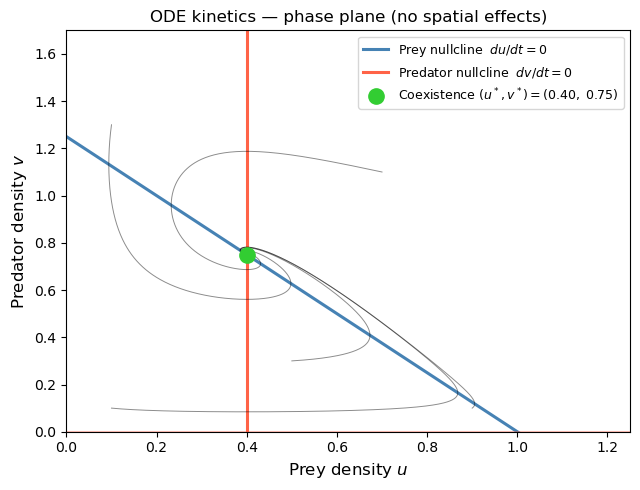

All trajectories converge to the coexistence equilibrium — it is a stable spiral.
Spatial taxis can destabilize this uniform state and generate patterns.


In [2]:
# ── ODE kinetics: phase plane (no spatial terms) ──────────────────────────
# Before adding space, it's useful to understand the local (ODE) dynamics.
# The PDE reaction terms are identical to this ODE system at every point in space.

def ode_rhs(t, y):
    u, v = y
    return [r*u*(1 - u/K) - alpha*u*v,
            beta*u*v - delta*v]

u_range = np.linspace(0, 1.3*K, 300)

# Nullclines
v_nullcline_u = r * (1 - u_range / K) / alpha   # du/dt = 0 (non-trivial)
u_nullcline_v = delta / beta                      # dv/dt = 0 (vertical)

fig, ax = plt.subplots(figsize=(6.5, 5))

ax.plot(u_range, v_nullcline_u, 'steelblue', lw=2.2, label='Prey nullcline  $du/dt = 0$')
ax.axvline(u_nullcline_v, color='tomato', lw=2.2, label='Predator nullcline  $dv/dt = 0$')
ax.axhline(0, color='tomato', lw=1.5, alpha=0.4)

# Several phase-plane trajectories
for u0, v0 in [(0.1, 0.1), (0.9, 0.1), (0.1, 1.3), (0.7, 1.1), (0.5, 0.3)]:
    sol = solve_ivp(ode_rhs, [0, 60], [u0, v0], max_step=0.05, dense_output=True)
    xy  = sol.sol(np.linspace(0, 60, 2000))
    ax.plot(xy[0], xy[1], 'k', lw=0.7, alpha=0.45)

ax.plot(u_star, v_star, 'o', ms=11, color='limegreen', zorder=6,
        label=f'Coexistence $(u^*, v^*) = ({u_star:.2f},\ {v_star:.2f})$')

ax.set_xlabel('Prey density $u$', fontsize=12)
ax.set_ylabel('Predator density $v$', fontsize=12)
ax.set_title('ODE kinetics — phase plane (no spatial effects)', fontsize=12)
ax.set_xlim(0, 1.25)
ax.set_ylim(0, 1.7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("All trajectories converge to the coexistence equilibrium — it is a stable spiral.")
print("Spatial taxis can destabilize this uniform state and generate patterns.")

In [3]:
# ── PDE spatial operators ─────────────────────────────────────────────────
# All functions use zero-flux (Neumann) BCs implemented via edge-padding:
# ghost cells equal the nearest interior cell, so ∂f/∂n = 0 at boundaries.

def laplacian_2d(f, dx):
    """Standard 5-point Laplacian with zero-flux boundary conditions."""
    fp = np.pad(f, 1, mode='edge')
    return (fp[2:, 1:-1] + fp[:-2, 1:-1] +
            fp[1:-1, 2:] + fp[1:-1, :-2] - 4*fp[1:-1, 1:-1]) / dx**2


def taxis_div_2d(phi, psi, dx):
    """
    Conservative finite-volume discretization of  ∇·(φ ∇ψ)
    with zero-flux boundary conditions.

    Strategy: compute fluxes at cell faces using face-averaged φ and
    one-sided ∂ψ/∂x (or ∂y) across the face, then take the divergence
    as the difference of fluxes across opposite faces.
    """
    phip = np.pad(phi, 1, mode='edge')   # (N+2) × (N+2)
    psip = np.pad(psi, 1, mode='edge')

    # ── x-direction faces: shape N × (N+1) ──────────────────────────────
    phi_fx  = (phip[1:-1, :-1] + phip[1:-1, 1:]) / 2      # avg φ at x-face
    dpsi_fx = (psip[1:-1, 1:]  - psip[1:-1, :-1]) / dx    # ∂ψ/∂x at face
    Fx      = phi_fx * dpsi_fx                             # face flux

    # ── y-direction faces: shape (N+1) × N ──────────────────────────────
    phi_fy  = (phip[:-1, 1:-1] + phip[1:, 1:-1]) / 2      # avg φ at y-face
    dpsi_fy = (psip[1:, 1:-1]  - psip[:-1, 1:-1]) / dx    # ∂ψ/∂y at face
    Fy      = phi_fy * dpsi_fy

    # ── Divergence = (east flux − west flux)/dx + (north − south)/dx ────
    return (Fx[:, 1:] - Fx[:, :-1]) / dx + (Fy[1:, :] - Fy[:-1, :]) / dx


def pde_rhs(u, v):
    """Compute du/dt and dv/dt for the full PDE system at one instant."""
    lap_u  = laplacian_2d(u, dx)
    lap_v  = laplacian_2d(v, dx)
    div_uv = taxis_div_2d(u, v, dx)   # ∇·(u ∇v) — used in prey equation
    div_vu = taxis_div_2d(v, u, dx)   # ∇·(v ∇u) — used in predator equation

    du = D_u*lap_u + chi_u*div_uv + r*u*(1 - u/K) - alpha*u*v
    dv = D_v*lap_v - chi_v*div_vu + beta*u*v - delta*v
    return du, dv

print("Spatial operators defined.")
print(f"Zero-flux BCs confirmed: boundary face fluxes = 0 by construction (edge padding).")

Spatial operators defined.
Zero-flux BCs confirmed: boundary face fluxes = 0 by construction (edge padding).


In [4]:
# ── Initial conditions and explicit-Euler time integration ────────────────
# Start near the spatially uniform coexistence equilibrium (u*, v*) with
# small random perturbations (5 %). Any spatial structure that emerges is
# driven entirely by the taxis and diffusion terms — not by the initial data.

np.random.seed(7)
u = u_star * (1 + 0.05 * np.random.randn(N, N))
v = v_star * (1 + 0.05 * np.random.randn(N, N))
u = np.clip(u, 1e-4, 2*K)
v = np.clip(v, 1e-4, None)

# Snapshot schedule: save at t = 0, 10, 20, 30, 40
save_steps  = {int(t / dt) for t in [10, 20, 30, 40]}
snaps_u     = [u.copy()]
snaps_v     = [v.copy()]
snap_t      = [0.0]

# Track spatially averaged densities every ~0.2 time units
track_every = max(1, n_steps // 200)
U_mean      = [u.mean()]
V_mean      = [v.mean()]
t_mean      = [0.0]

print("Running PDE simulation (explicit Euler)...")
for step in range(n_steps):
    du, dv = pde_rhs(u, v)
    u = np.clip(u + dt * du, 1e-6, 3*K)   # non-negativity safeguard
    v = np.clip(v + dt * dv, 1e-6, None)

    if step + 1 in save_steps:
        snaps_u.append(u.copy())
        snaps_v.append(v.copy())
        snap_t.append((step + 1) * dt)

    if (step + 1) % track_every == 0:
        U_mean.append(u.mean())
        V_mean.append(v.mean())
        t_mean.append((step + 1) * dt)

print(f"Done.  Final mean densities:  u = {u.mean():.4f}  (u* = {u_star:.4f})"
      f",  v = {v.mean():.4f}  (v* = {v_star:.4f})")

Running PDE simulation (explicit Euler)...
Done.  Final mean densities:  u = 0.3999  (u* = 0.4000),  v = 0.7307  (v* = 0.7500)


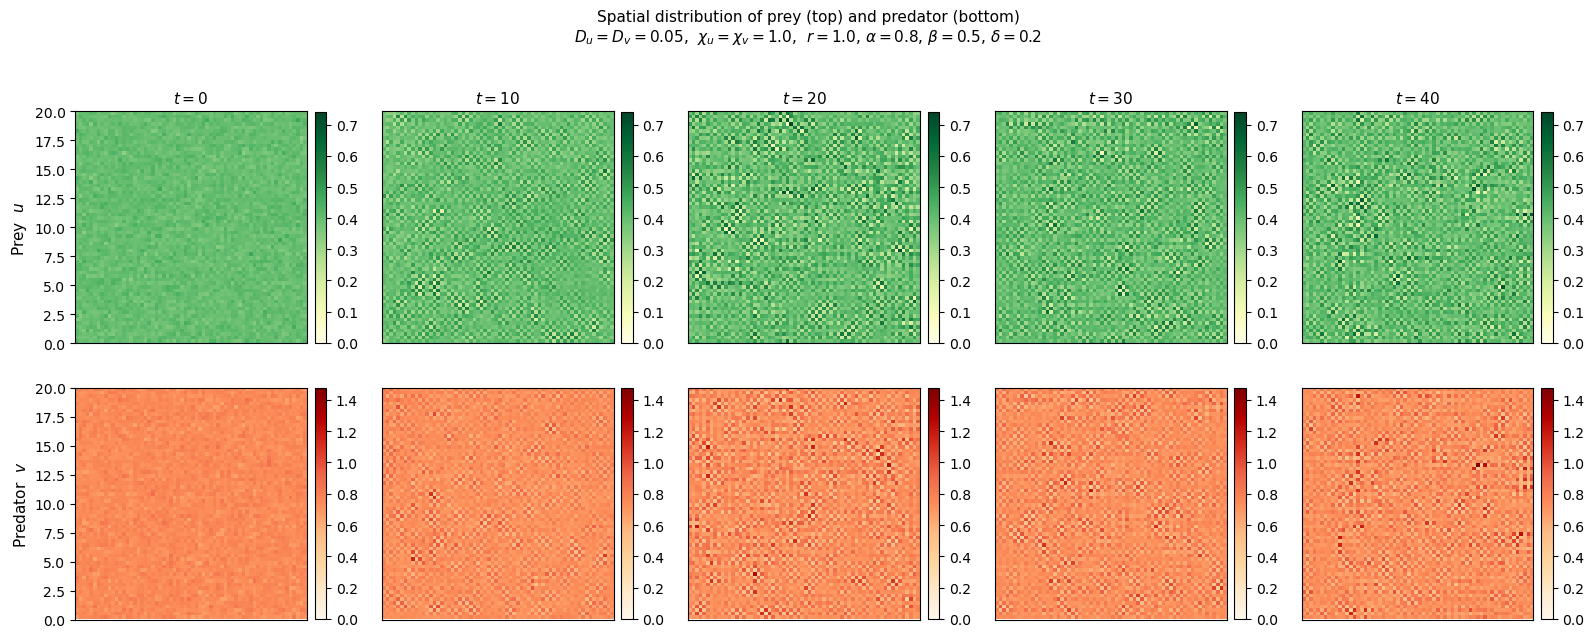

In [5]:
# ── Spatial pattern snapshots ─────────────────────────────────────────────
# Top row: prey density u(x,y,t).  Bottom row: predator density v(x,y,t).
# Colour scales are fixed across time for direct comparison.

u_vmax = max(s.max() for s in snaps_u)
v_vmax = max(s.max() for s in snaps_v)

n_snaps = len(snaps_u)
fig, axes = plt.subplots(2, n_snaps, figsize=(3.2 * n_snaps, 6.4))

for col, (su, sv, t) in enumerate(zip(snaps_u, snaps_v, snap_t)):

    # Prey row
    im1 = axes[0, col].imshow(
        su, cmap='YlGn', origin='lower', extent=[0, L, 0, L],
        vmin=0, vmax=u_vmax, interpolation='nearest')
    axes[0, col].set_title(f'$t = {t:.0f}$', fontsize=11)
    if col == 0:
        axes[0, col].set_ylabel('Prey  $u$', fontsize=11)
    else:
        axes[0, col].set_yticks([])
    axes[0, col].set_xticks([])
    plt.colorbar(im1, ax=axes[0, col], fraction=0.046, pad=0.03)

    # Predator row
    im2 = axes[1, col].imshow(
        sv, cmap='OrRd', origin='lower', extent=[0, L, 0, L],
        vmin=0, vmax=v_vmax, interpolation='nearest')
    if col == 0:
        axes[1, col].set_ylabel('Predator  $v$', fontsize=11)
    else:
        axes[1, col].set_yticks([])
    axes[1, col].set_xticks([])
    plt.colorbar(im2, ax=axes[1, col], fraction=0.046, pad=0.03)

fig.suptitle(
    f'Spatial distribution of prey (top) and predator (bottom)\n'
    f'$D_u = D_v = {D_u}$,  $\\chi_u = \\chi_v = {chi_u}$,  '
    f'$r={r}$, $\\alpha={alpha}$, $\\beta={beta}$, $\\delta={delta}$',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

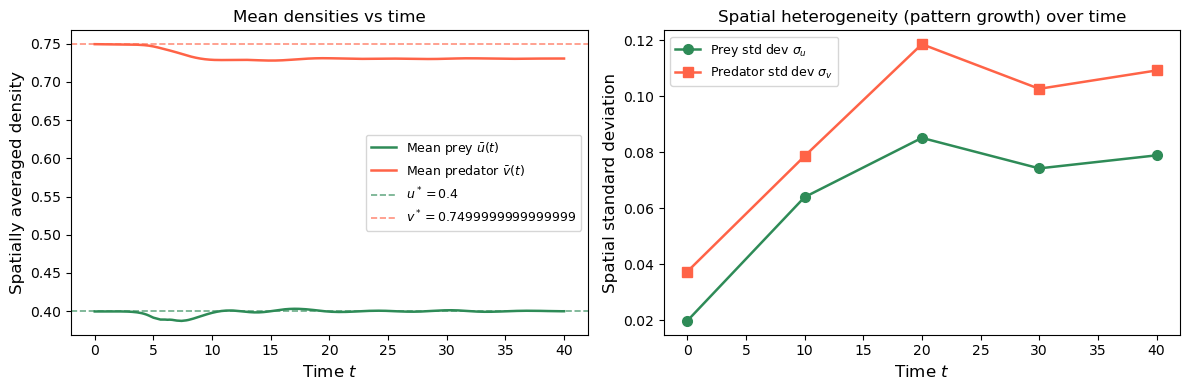

In [6]:
# ── Population dynamics and spatial heterogeneity over time ──────────────
# Left:  spatially averaged densities track the ODE equilibrium.
# Right: spatial standard deviation measures how heterogeneous the field is
#        — a rising std-dev is the signature of pattern formation.

snap_std_u = [np.std(s) for s in snaps_u]
snap_std_v = [np.std(s) for s in snaps_v]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Mean densities
ax1.plot(t_mean, U_mean, color='seagreen', lw=1.8, label='Mean prey $\\bar{u}(t)$')
ax1.plot(t_mean, V_mean, color='tomato',   lw=1.8, label='Mean predator $\\bar{v}(t)$')
ax1.axhline(u_star, color='seagreen', ls='--', lw=1.2, alpha=0.7,
            label=f'$u^* = {u_star}$')
ax1.axhline(v_star, color='tomato',   ls='--', lw=1.2, alpha=0.7,
            label=f'$v^* = {v_star}$')
ax1.set_xlabel('Time $t$', fontsize=12)
ax1.set_ylabel('Spatially averaged density', fontsize=12)
ax1.set_title('Mean densities vs time', fontsize=12)
ax1.legend(fontsize=9)

# Spatial heterogeneity
ax2.plot(snap_t, snap_std_u, 'o-', color='seagreen', ms=7, lw=1.8,
         label='Prey std dev $\\sigma_u$')
ax2.plot(snap_t, snap_std_v, 's-', color='tomato',   ms=7, lw=1.8,
         label='Predator std dev $\\sigma_v$')
ax2.set_xlabel('Time $t$', fontsize=12)
ax2.set_ylabel('Spatial standard deviation', fontsize=12)
ax2.set_title('Spatial heterogeneity (pattern growth) over time', fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Results and Interpretation

### What the spatial snapshots show

At $t = 0$ both populations are nearly uniform — only 5 % random noise perturbs the coexistence equilibrium. Over time, taxis amplifies these perturbations into coherent spatial structures:

- **Prey** (green) cluster into high-density patches away from predators.
- **Predators** (orange-red) aggregate in the regions where prey is densest, chasing the prey clusters.

The spatial standard deviation plot confirms that heterogeneity grows over time — this is **taxis-driven pattern formation**, analogous to Turing instability but driven by directed movement rather than differential diffusion.

### Why the mean densities stay near $(u^*, v^*)$

The spatial average $\bar{u}(t)$ and $\bar{v}(t)$ remain close to the coexistence equilibrium. This makes sense: the zero-flux boundary conditions conserve total population up to the reaction terms, and the reaction terms at equilibrium are balanced. Taxis and diffusion only redistribute individuals in space — they do not change the total count.

### Role of each term

| Term | Alone | Combined effect |
|:----:|:-----:|:---------------:|
| Diffusion only ($\chi = 0$) | Smooths patterns, stabilizes uniform state | Cannot generate patterns with equal diffusion |
| Taxis only ($D = 0$) | Causes aggregation / collapse | Unstable — needs diffusion to regularize |
| **Both** | Compete against each other | Produces stable, sustained spatial patterns |

### Real-world analogy

This model is directly relevant to ecological systems where spatial movement matters — wolf and deer populations across a landscape, plankton blooms and their grazers in the ocean, or bacterial populations and their predatory phages. The key insight is that **directed movement (taxis) alone is sufficient to break spatial uniformity**, even when the ODE kinetics predict a stable, uniform coexistence state.